# IMPORTS

In [13]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
from pydub import AudioSegment
from pydub.utils import which
from sklearn.model_selection import GroupShuffleSplit
import warnings
import cv2
from io import BytesIO
from PIL import Image

# CREMA-D

## Load CREMA-D

In [6]:
dataset_folder = "dataset\\CREMA-D\\AudioWAV\\"

data = []

emotion_map = {
    "ANG": "Anger",
    "DIS": "Disgust",
    "FEA": "Fear",
    "HAP": "Happy",
    "NEU": "Neutral",
    "SAD": "Sad",
}


for file in os.listdir(dataset_folder):
    filename, _ = os.path.splitext(file)

    parts = filename.split("_")

    # Speaker
    speaker = parts[0]

    # Path
    path = os.path.join(dataset_folder, file)

    # Emotion
    emotion_code = parts[2]
    emotion = emotion_map.get(emotion_code, "Unknown")

    data.append([speaker, path, emotion])

dataset = pd.DataFrame(data, columns=["speaker", "path", "emotion"])
print(dataset.count())

speaker    7442
path       7442
emotion    7442
dtype: int64


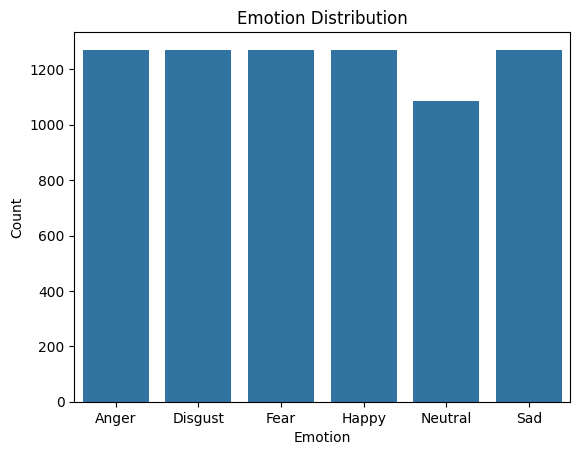

In [11]:
sns.countplot(x="emotion", data=dataset)
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

In [7]:
def create_csv(df: pd.DataFrame, output_csv: str):
    df.to_csv(output_csv, index=False)

os.makedirs("CSVs", exist_ok=True)
    
create_csv(dataset, "CSVs\\dataset.csv")

## Remove silence

In [ ]:
AudioSegment.converter = which("ffmpeg")

location = "dataset_silenced\\"
os.makedirs(location, exist_ok=True)


def detect_leading_silence(dls_audio):
    dls_chunk_size = 10
    dls_silence_threshold = -50.0

    trim_ms = 0
    dls_audio_length = len(dls_audio)

    while trim_ms < dls_audio_length:
        chunk_dBFS = dls_audio[trim_ms : trim_ms + dls_chunk_size].dBFS
        if chunk_dBFS > dls_silence_threshold:
            break
        trim_ms += dls_chunk_size

    return trim_ms


name = 0
errors = 0
file_data = []

# Process each audio file, remove leading and trailing silence, and save the new audio files
for _, row in dataset.iterrows():
    file_name = f"{location}{name}.wav"

    try:
        audio = AudioSegment.from_file(row["path"], format="wav")
    except:  # noqa: E722
        audio = AudioSegment.from_file(row["path"])

    start_trim = detect_leading_silence(audio)
    end_trim = detect_leading_silence(audio.reverse())

    duration = len(audio)
    new_audio = audio[start_trim : duration - end_trim]

    if len(new_audio) > 0:
        os.makedirs(os.path.dirname(file_name), exist_ok=True)
        new_audio.export(file_name, format="wav")
    else:
        audio.export(file_name, format="wav")
        errors += 1
        print(f"Error processing {row['path']}, saved original audio.")

    file_data.append([row["speaker"], file_name, row["emotion"]])
    name += 1

dataset_silenced = pd.DataFrame(file_data, columns=["speaker", "path", "emotion"])
create_csv(dataset_silenced, "CSVs\\dataset_silenced.csv")

Error processing dataset\CREMA-D\AudioWAV\1076_MTI_SAD_XX.wav, saved original audio.


## Split dataset

In [9]:
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, temp_idx = next(gss.split(dataset_silenced, groups=dataset_silenced["speaker"]))

gss = GroupShuffleSplit(test_size=0.5, n_splits=1, random_state=42)
val_idx, test_idx = next(
    gss.split(
        dataset_silenced.loc[temp_idx], groups=dataset_silenced.loc[temp_idx]["speaker"]
    )
)

train_df = dataset_silenced.iloc[train_idx].reset_index(drop=True)
val_df = dataset_silenced.iloc[temp_idx].iloc[val_idx].reset_index(drop=True)
test_df = dataset_silenced.iloc[temp_idx].iloc[test_idx].reset_index(drop=True)

print(f"Train set: {len(train_df)} samples")
print(f"Validation set: {len(val_df)} samples")
print(f"Test set: {len(test_df)} samples")

create_csv(train_df, "CSVs\\train.csv")
create_csv(val_df, "CSVs\\val.csv")
create_csv(test_df, "CSVs\\test.csv")

Train set: 5890 samples
Validation set: 732 samples
Test set: 820 samples


## Data augmentation

In [ ]:
import random

location = "dataset_augmented\\"
os.makedirs(location, exist_ok=True)


def noise(n_data):
    noise_amp = 0.005 * np.random.uniform() * np.max(np.abs(n_data))
    return n_data + noise_amp * np.random.normal(size=n_data.shape[0])


def stretch(s_data):
    s_rate = np.random.uniform(0.95, 1.05)
    return librosa.effects.time_stretch(s_data, rate=s_rate)


def pitch(p_data, p_sampling_rate):
    p_pitch_factor = np.random.uniform(-1, 1)
    return librosa.effects.pitch_shift(
        p_data, sr=p_sampling_rate, n_steps=p_pitch_factor
    )


name = 0
file_data = []

# Process each audio file, apply random augmentation, and save the new audio files
for _, row in train_df.iterrows():
    data, sampling_rate = librosa.load(row["path"], sr=None)

    # Original audio
    file_name = f"{location}{name}.wav"
    sf.write(file_name, data, sampling_rate)

    file_data.append([row["speaker"], file_name, row["emotion"]])
    name += 1

    # Randomly select an augmentation type
    aug_type = random.choices(
        ["noise", "stretch", "pitch"], weights=[0.4, 0.3, 0.3], k=1
    )[0]

    augment_map = {
        "noise": lambda: noise(data),
        "stretch": lambda: stretch(data),
        "pitch": lambda: pitch(data, sampling_rate),
    }

    aug_data = augment_map[aug_type]()

    file_name = f"{location}{name}.wav"
    sf.write(file_name, aug_data, sampling_rate)

    file_data.append([row["speaker"], file_name, row["emotion"]])
    name += 1

    print(f"Processed {name} files", end="\r", flush=True)


train_df_augmented = pd.DataFrame(file_data, columns=["speaker", "path", "emotion"])
create_csv(train_df_augmented, "CSVs\\dataset_augmented.csv")

# CONVERT TO MEL SPECTROGRAM

## Config

In [ ]:
location = "features\\images\\"
csv_dir = "CSVs\\"

MIN_SAMPLES = 2048
TARGET_DURATION = 3.0  # seconds
IMG_SIZE = 224

# Mel params 
# Đây là số lượng dải Mel sẽ được sử dụng để tạo ra spectrogram. 
# Số lượng này ảnh hưởng đến độ phân giải của spectrogram và 
# khả năng mô hình học được các đặc trưng quan trọng từ dữ liệu âm thanh.
N_MELS = 128

# Đây là kích thước của cửa sổ FFT được sử dụng để tính toán spectrogram.
# Kích thước này ảnh hưởng đến độ phân giải tần số của spectrogram và
# khả năng mô hình học được các đặc trưng tần số quan trọng từ dữ liệu âm thanh.
N_FFT = 1024  

# Đây là khoảng cách giữa các cửa sổ FFT liên tiếp khi tính toán spectrogram.
# Khoảng cách này ảnh hưởng đến độ phân giải thời gian của spectrogram và
# khả năng mô hình học được các đặc trưng thời gian quan trọng từ dữ liệu âm thanh.
HOP_LENGTH = 256  

## Run

In [ ]:
# FIX AUDIO LENGTH
def fix_length(audio: np.ndarray, sr: int) -> np.ndarray:
    target_len = int(sr * TARGET_DURATION)

    if len(audio) > target_len:
        audio = audio[:target_len]

    elif len(audio) < target_len:
        pad = target_len - len(audio)
        audio = np.pad(audio, (0, pad))

    return audio


# AUDIO -> MEL IMAGE
def graph_spectrogram(gs_audio, sr: int | float | None = None) -> np.ndarray:

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        # If input is path
        if isinstance(gs_audio, str):
            audio, loaded_sr = librosa.load(gs_audio, sr=None)
            sr = int(loaded_sr)

        else:
            audio = gs_audio
            if sr is None:
                raise ValueError("sr required when input is waveform")
            sr = int(sr)

        # fix duration
        audio = fix_length(audio, sr)

        # mel spectrogram
        mel = librosa.feature.melspectrogram(
            y=audio, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
        )

        mel_db = librosa.power_to_db(mel, ref=np.max)

        # plot no border
        fig, ax = plt.subplots(figsize=(2.24, 2.24))
        fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
        ax.axis("off")

        librosa.display.specshow(
            mel_db, sr=sr, hop_length=HOP_LENGTH, cmap="inferno", ax=ax
        )

        buf = BytesIO()
        fig.savefig(buf, format="png", dpi=100)
        buf.seek(0)

        img = np.array(Image.open(buf))[:, :, :3]

        plt.close(fig)
        buf.close()

        return img


# CREATE IMAGE DATASET
def prepare_images(pi_df: pd.DataFrame, pi_name: str):
    save_dir = os.path.join(location, pi_name)
    os.makedirs(save_dir, exist_ok=True)
    os.makedirs(csv_dir, exist_ok=True)

    file_data = []
    skipped = 0
    counter = 1
    total = len(pi_df)

    for _, row in pi_df.iterrows():
        try:
            raw, sr = librosa.load(row["path"], sr=None)

            if len(raw) < MIN_SAMPLES:
                skipped += 1
                continue

            img = graph_spectrogram(raw, sr)

            img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            img_path = os.path.join(save_dir, f"{counter}.png")
            cv2.imwrite(img_path, img)

            file_data.append([row["emotion"], img_path])

            print(f"\r{pi_name}: {counter}/{total}", end="", flush=True)

            counter += 1

        except Exception as e:
            print(f"\nError: {row['path']} -> {e}")

    print(f"\n{pi_name} done | saved={counter - 1} | skipped={skipped}")

    result_df = pd.DataFrame(file_data, columns=["emotion", "path"])

    result_df.to_csv(os.path.join(csv_dir, f"{pi_name}_images.csv"), index=False)


# RUN
prepare_images(train_df_augmented, "train")
prepare_images(val_df, "val")
prepare_images(test_df, "test")